In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.append("../..")

from src.classifical_features import build_monthly_features
from src.configs.settings import Settings
from src.visualization.visualization import (
    plot_best_predictions,
    plot_overall_metrics_comparison,
    plot_panel_metrics_distributions,
    plot_worst_predictions,
)

settings = Settings()

In [2]:
data_dir = Path("../../data")

In [3]:
features_df = pd.read_csv(data_dir / "processed" / "mirrors_clusters.csv")
mirrors_ts_df = pd.read_csv(data_dir / "processed" / "filtered_mirrors_ts.csv")

In [4]:
features = build_monthly_features(mirrors_ts_df, settings)
features["panel_id"] = features[settings.columns.id].astype(str)

Processing panels: 100%|██████████| 131/131 [00:00<00:00, 299.64it/s]


In [5]:
from src.model_selection import temporal_panel_split_by_size
from src.seasonal_naive_utilities import evaluate_seasonal_naive, train_seasonal_naive

regression_splits = temporal_panel_split_by_size(
    features,
    panel_column='article',
    time_column='date',
    test_size=3,
    val_size=None
)

In [6]:
seasonal_naive_model = train_seasonal_naive(
    train_df=regression_splits.train,
    val_df=regression_splits.val,
    settings=settings,
    seasonal_period=12,
)

results = evaluate_seasonal_naive(
    model=seasonal_naive_model,
    splits=regression_splits,
    settings=settings,
)

/home/nikita/projects/microniches/notebooks/niches/../../src/seasonal_naive_utilities/evaluate.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.iloc[warmup:])
Evaluating test panels: 100%|██████████| 131/131 [00:00<00:00, 1908.10it/s]


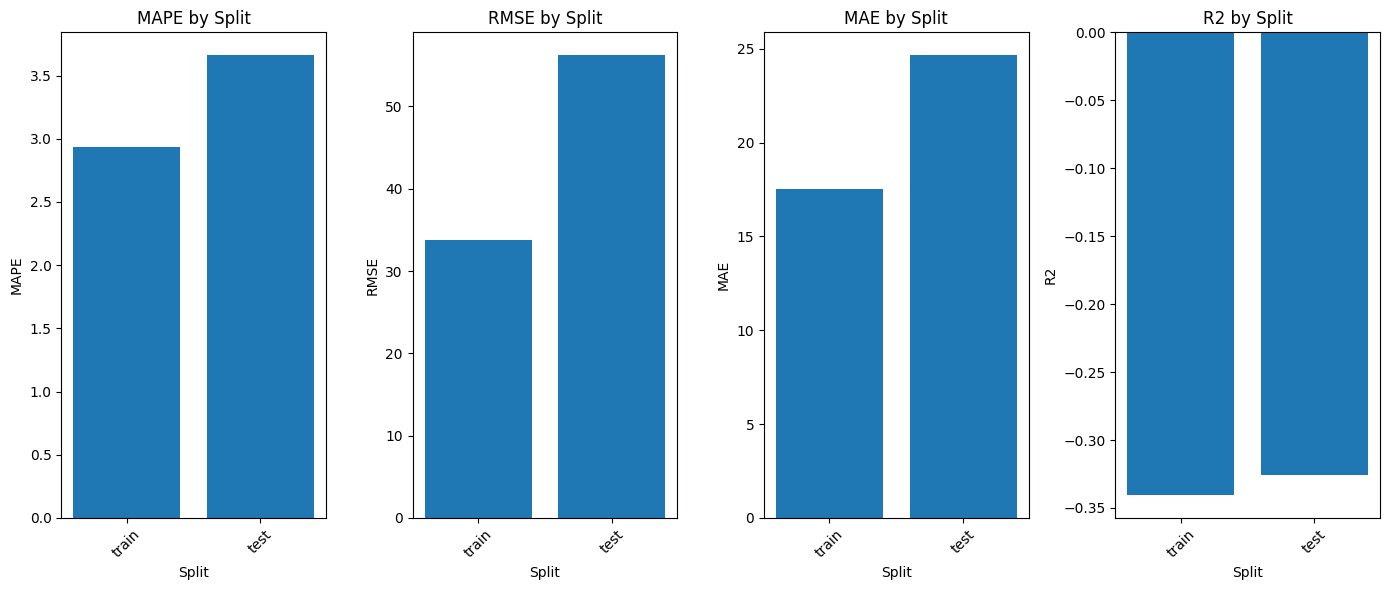

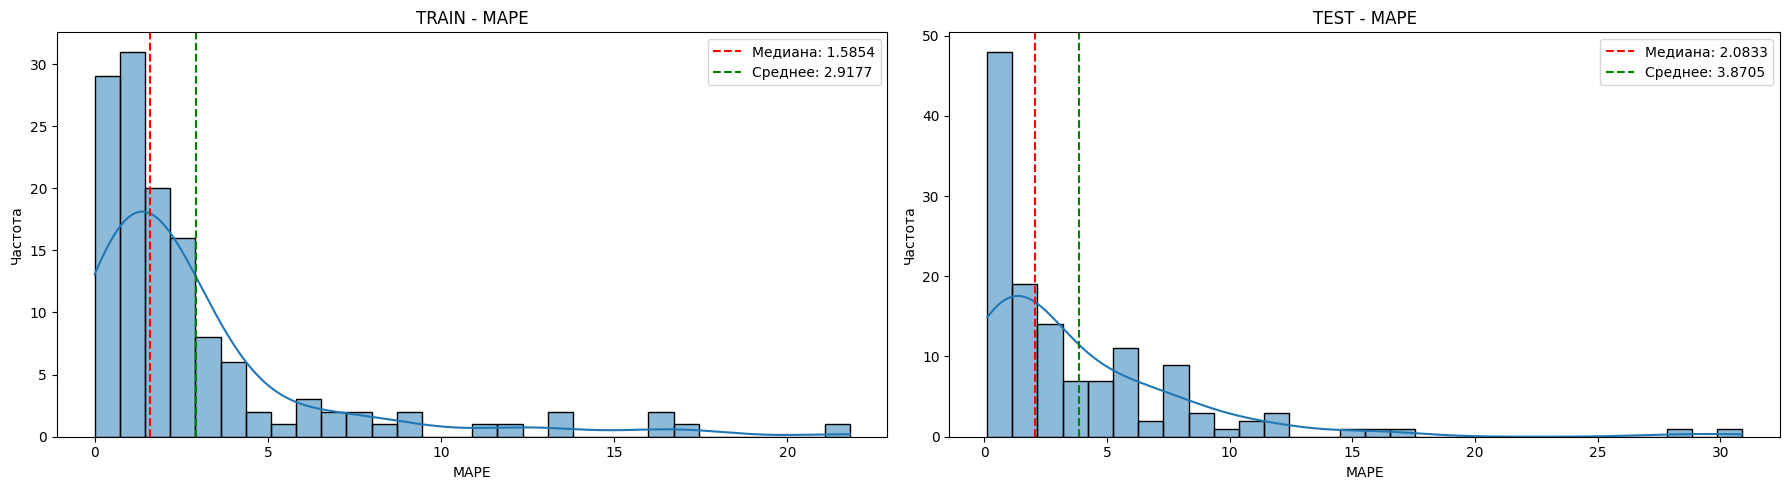

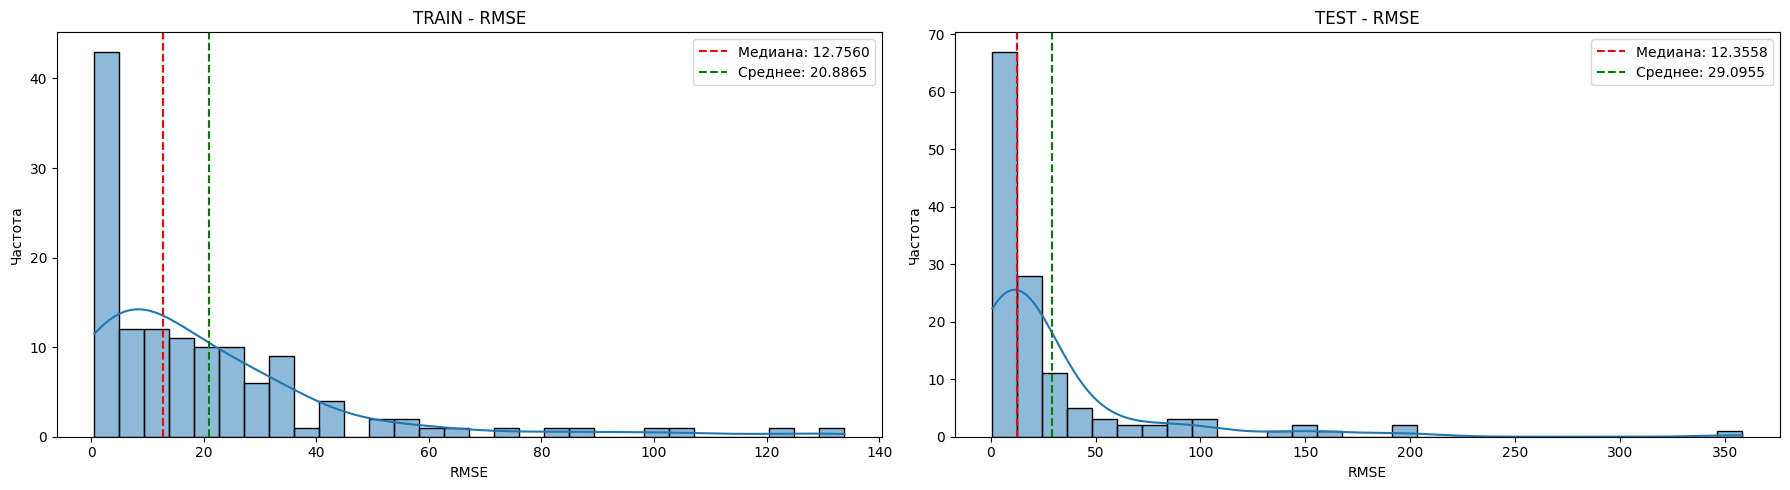

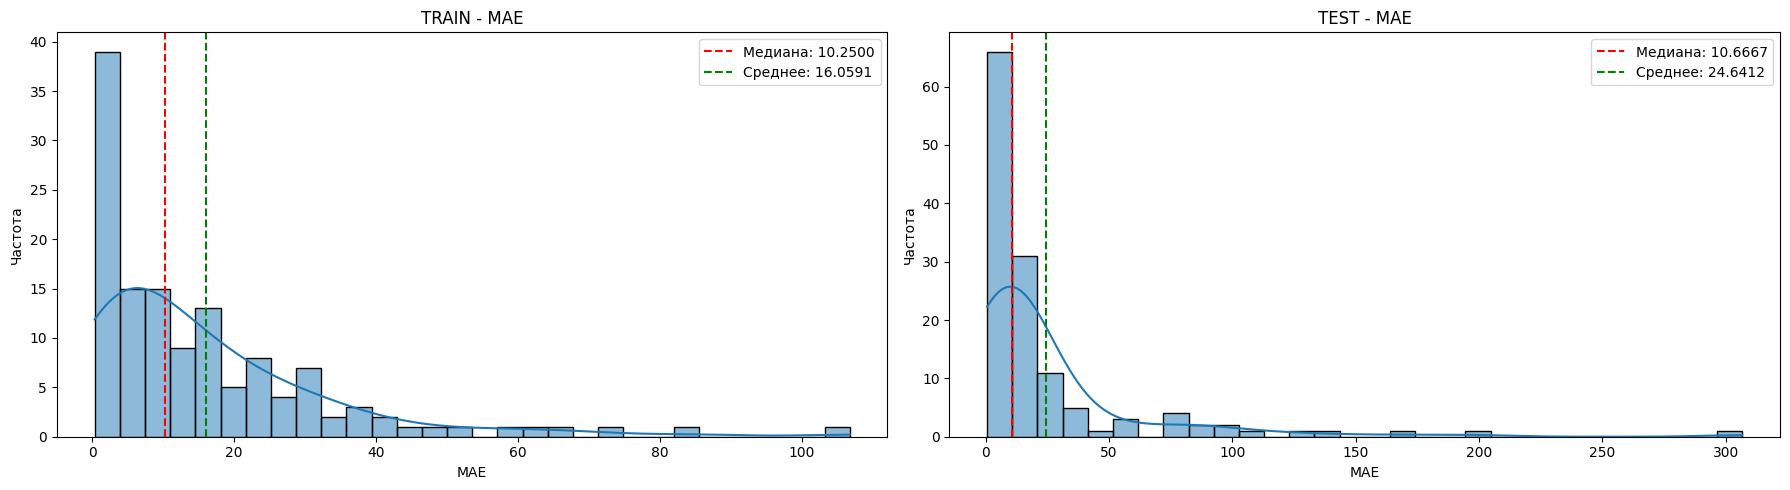

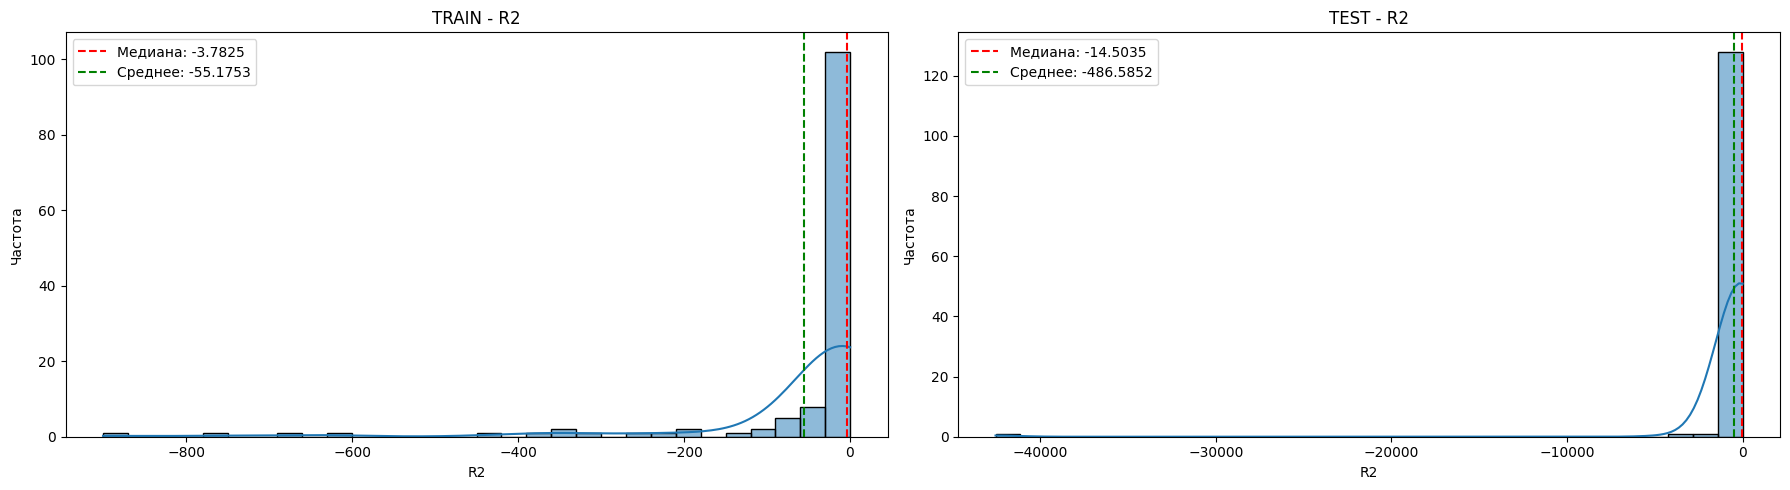

In [7]:
overall_df = results.get_overall_metrics_df()
panel_df = results.get_panel_metrics_df()


plot_overall_metrics_comparison(results)

plot_panel_metrics_distributions(
    results=results,
    metrics_to_plot=["mape", "rmse", "mae", "r2"],
)

In [8]:
plot_best_predictions(
    results=results,
    n_best=5,
    metric="rmse",
    split_name="test",
)

In [9]:
plot_worst_predictions(
    results=results,
    n_worst=5,
    metric="rmse",
    split_name="test",
)